In [271]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore

### Importing dataset

In [272]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [273]:
location = "Bamako"
data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/{location}/t0/train-data-{location}-lt6.csv", index_col=False)
test_data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/{location}/t0/test-data-{location}-lt6.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [274]:
data = data.dropna()
test_data = test_data.dropna()

In [275]:
test_data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_bamako_t6
0,2020,6,1,16,15,10.56,-0.54,17.52,-7.05,14.00,...,25550,0,0.0,0.0,174.64,277.06,500.00,500.00,500.00,0.0
1,2020,6,1,16,45,11.28,-1.53,17.70,-7.05,14.00,...,20700,0,0.0,0.0,180.49,235.93,500.00,500.00,500.00,0.0
2,2020,6,1,17,15,16.71,-7.01,12.58,-1.80,12.67,...,375,9975,9975.0,19025.0,147.53,188.30,215.01,220.01,222.01,0.0
3,2020,6,1,17,30,10.33,-3.42,16.80,-6.97,11.37,...,9300,30950,9300.0,0.0,150.96,181.57,214.06,227.50,500.00,0.0
4,2020,6,1,17,45,10.29,-3.42,11.37,-1.84,16.85,...,2675,9600,13850.0,0.0,152.61,182.02,219.01,224.56,500.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12050,2022,9,30,11,45,14.47,-1.35,10.20,-0.63,14.00,...,350,0,0.0,0.0,246.72,277.97,500.00,500.00,500.00,1.0
12051,2022,9,30,12,0,11.41,-1.62,14.42,-1.49,14.96,...,10650,1975,0.0,0.0,232.02,242.33,247.95,500.00,500.00,1.0
12052,2022,9,30,12,15,15.23,-1.44,14.38,-1.58,14.87,...,7075,6525,4000.0,0.0,228.89,238.21,252.37,265.05,500.00,1.0
12053,2022,9,30,12,30,16.94,-0.50,14.20,-1.75,14.47,...,17000,575,4325.0,17000.0,226.56,230.65,253.48,267.56,308.48,1.0


In [276]:
original_test_data = test_data.copy()

#### Choosing field to include in the data

In [277]:
lead_time = 6

In [278]:
# Presence or absence of convection in Dakar at time t+1
target_index = f"Cb_{location.lower()}_t{lead_time}"

# Input at time t
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')
data = data[field]
test_data = test_data[field]

In [279]:
data.describe()

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_bamako_t6
count,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,...,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000,60190.000000
mean,2011.523010,7.565842,15.715252,13.036136,22.316332,13.066152,-4.695718,13.069522,-4.508188,13.212443,...,8576.377305,7264.385695,6140.508390,5097.105832,107.505061,140.208846,201.470712,252.133490,295.665559,0.178269
std,4.617402,1.037042,8.830473,6.884804,16.749346,1.906520,2.775781,1.880818,2.800766,1.744662,...,8399.674475,8408.821392,8168.916166,7653.635664,79.386517,85.286443,140.462278,160.740236,167.570855,0.382742
min,2004.000000,6.000000,1.000000,0.000000,0.000000,10.020000,-8.990000,10.020000,-8.990000,10.020000,...,100.000000,0.000000,0.000000,0.000000,1.000000,3.160000,11.050000,16.120000,23.350000,0.000000
25%,2008.000000,7.000000,8.000000,7.000000,0.000000,11.500000,-7.050000,11.550000,-6.880000,11.820000,...,2425.000000,1175.000000,0.000000,0.000000,42.430000,68.660000,91.970000,117.240000,144.227500,0.000000
50%,2011.000000,8.000000,16.000000,15.000000,30.000000,12.850000,-5.080000,12.850000,-4.810000,13.300000,...,6000.000000,4425.000000,3075.000000,1725.000000,86.020000,122.325000,163.780000,206.190000,253.620000,0.000000
75%,2016.000000,8.000000,23.000000,19.000000,30.000000,14.420000,-2.520000,14.380000,-2.250000,14.110000,...,11950.000000,10350.000000,8825.000000,7300.000000,159.000000,202.320000,267.150000,500.000000,500.000000,0.000000
max,2019.000000,9.000000,31.000000,23.000000,45.000000,17.970000,0.990000,17.970000,0.990000,17.970000,...,105300.000000,91100.000000,86750.000000,86350.000000,354.680000,369.500000,500.000000,500.000000,500.000000,1.000000


### Exploratory data analysis

In [280]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [281]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [282]:
to_scale = wavelet_power + storm_size + distance

In [283]:
transform = True
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [284]:
train, validation = train_test_split(data, test_size=0.2, random_state=12)

In [285]:
train

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_bamako_t6
5038,44.777226,2.645751,3.872983,4.358899,6.708204,15.05,-0.59,14.42,-0.63,11.14,...,9.566265,7.130899,8.242756,6.802395,5.170768,5.361057,5.508416,5.603631,5.632107,0.0
35596,44.866469,2.645751,3.316625,4.358899,6.708204,10.38,-8.31,10.83,-6.83,12.22,...,5.298317,8.294050,9.280333,9.784141,3.663562,3.963286,4.328098,4.409155,4.684259,0.0
16024,44.810713,2.645751,3.316625,4.242641,0.000000,13.61,-5.53,13.34,-1.98,12.58,...,9.848239,8.532082,8.174703,10.361703,4.560487,5.167753,5.366023,5.381923,5.434115,0.0
32769,44.855323,2.828427,3.741657,2.000000,3.872983,12.85,-4.85,13.39,-5.66,12.62,...,8.465900,9.237469,-18.420681,-18.420681,4.442651,4.479947,4.721085,6.214608,6.214608,0.0
51009,44.911023,2.828427,3.605551,1.414214,6.708204,15.23,-2.65,13.97,-1.80,15.00,...,7.261927,8.006368,-18.420681,-18.420681,5.360823,5.421331,5.425523,6.214608,6.214608,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40177,44.877611,3.000000,3.162278,3.872983,0.000000,12.58,-8.99,11.82,-2.61,10.78,...,8.707814,8.262301,-18.420681,-18.420681,3.559055,5.268786,5.299267,6.214608,6.214608,0.0
19709,44.821870,2.645751,1.000000,2.449490,5.477226,12.31,-1.89,10.87,-2.92,13.25,...,8.678461,6.684612,8.794825,7.090077,5.255671,5.282645,5.367890,5.371242,5.385779,0.0
58758,44.933284,2.828427,4.242641,4.472136,3.872983,11.59,-3.10,13.43,-3.24,14.38,...,8.174703,8.360539,9.059517,9.156412,4.210051,4.673483,4.969883,5.155832,5.181165,0.0
38555,44.877611,2.645751,5.291503,4.582576,0.000000,15.63,-8.54,15.05,-3.55,15.32,...,9.845594,8.728264,9.925738,8.188689,4.664099,4.774153,5.019793,5.199491,5.261238,0.0


In [286]:
neg, pos = train[target_index].value_counts()
total = neg + pos
print(f"Negative: {neg} and Positive: {pos}. That is {pos/total:.2f} of the total.")

Negative: 39515 and Positive: 8637. That is 0.18 of the total.


In [287]:
x_train = train.drop([target_index], axis=1)
y_train = train[target_index]

x_val = validation.drop([target_index], axis=1)
y_val = validation[target_index]

x_test = test_data.drop([target_index], axis=1)
y_test = test_data[target_index]

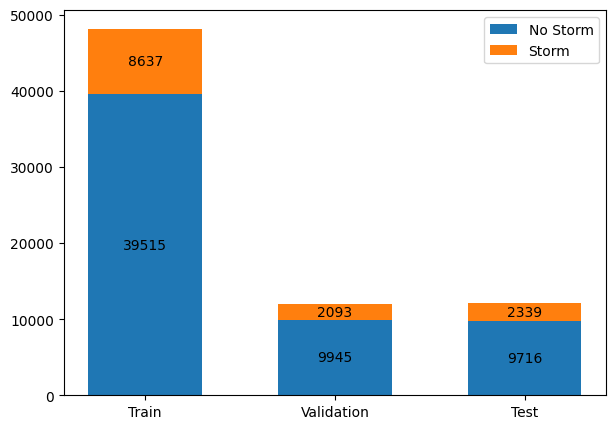

In [288]:
type = ('Train', 'Validation', 'Test')

storm_counts = {
    'No Storm': np.array([y_train.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]]),
    'Storm': np.array([y_train.value_counts()[1], y_val.value_counts()[1] , y_test.value_counts()[1]]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(3)

for mode, count in storm_counts.items():
    p = ax.bar(type, count, width, label=mode, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.legend()

plt.show()

#### Normalising the features

In [289]:
x_test

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,44.944410,2.44949,1.000000,4.000000,3.872983,10.56,-0.54,17.52,-7.05,14.00,...,9.441452,10.148393,-18.420681,-18.420681,-18.420681,5.162727,5.624234,6.214608,6.214608,6.214608
1,44.944410,2.44949,1.000000,4.000000,6.708204,11.28,-1.53,17.70,-7.05,14.00,...,8.022897,9.937889,-18.420681,-18.420681,-18.420681,5.195675,5.463535,6.214608,6.214608,6.214608
2,44.944410,2.44949,1.000000,4.123106,3.872983,16.71,-7.01,12.58,-1.80,12.67,...,9.853509,5.926926,9.207837,9.207837,9.853509,4.994032,5.238036,5.370685,5.393673,5.402722
3,44.944410,2.44949,1.000000,4.123106,5.477226,10.33,-3.42,16.80,-6.97,11.37,...,9.137770,9.137770,10.340128,9.137770,-18.420681,5.017015,5.201641,5.366256,5.427150,6.214608
4,44.944410,2.44949,1.000000,4.123106,6.708204,10.29,-3.42,11.37,-1.84,16.85,...,9.536041,7.891705,9.169518,9.536041,-18.420681,5.027886,5.204117,5.389117,5.414143,6.214608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12050,44.966654,3.00000,5.477226,3.316625,6.708204,14.47,-1.35,10.20,-0.63,14.00,...,9.177301,5.857933,-18.420681,-18.420681,-18.420681,5.508254,5.627513,6.214608,6.214608,6.214608
12051,44.966654,3.00000,5.477226,3.464102,0.000000,11.41,-1.62,14.42,-1.49,14.96,...,9.259131,9.273315,7.588324,-18.420681,-18.420681,5.446824,5.490300,5.513227,6.214608,6.214608
12052,44.966654,3.00000,5.477226,3.464102,3.872983,15.23,-1.44,14.38,-1.58,14.87,...,7.362011,8.864323,8.783396,8.294050,-18.420681,5.433242,5.473153,5.530896,5.579918,6.214608
12053,44.966654,3.00000,5.477226,3.464102,5.477226,16.94,-0.50,14.20,-1.75,14.47,...,7.025538,9.740969,6.354370,8.372167,9.740969,5.423010,5.440901,5.535285,5.589344,5.731657


In [290]:
# normalise data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [291]:
#dump(scaler, 'scaler-Selibaby.bin', compress=True)

In [292]:
initial_bias = np.log(pos/neg)
output_bias = tf.keras.initializers.Constant(value=initial_bias)

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(30,)),
  tf.keras.layers.Dense(16, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dropout(0.2),    
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:
  layer.kernel_regularizer = l1_reg

cl_thresholds = 0.25

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=METRICS)

In [293]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [294]:
EPOCHS = 500
BATCH_SIZE = 1024

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)


# train the model
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=EPOCHS, 
                          callbacks = [early_stopping],
                          batch_size = BATCH_SIZE,         
                          validation_data=(x_val, y_val),
                        )

Epoch 1/500


48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - auc: 0.4369 - bs: 0.1780 - f1_score: 0.1545 - loss: 0.5668 - prc: 0.1541 - precision: 0.1305 - recall: 0.1905 - tn: 19968.2441 - tp: 151.8367 - val_auc: 0.5092 - val_bs: 0.1461 - val_f1_score: 0.1132 - val_loss: 0.4711 - val_prc: 0.1777 - val_precision: 0.1795 - val_recall: 0.0827 - val_tn: 9943.0000 - val_tp: 0.0000e+00
Epoch 2/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.5302 - bs: 0.1505 - f1_score: 0.1550 - loss: 0.4813 - prc: 0.1918 - precision: 0.1917 - recall: 0.1302 - tn: 20919.0000 - tp: 6.9592 - val_auc: 0.5958 - val_bs: 0.1418 - val_f1_score: 0.1608 - val_loss: 0.4549 - val_prc: 0.2183 - val_precision: 0.2344 - val_recall: 0.1223 - val_tn: 9942.0000 - val_tp: 3.0000
Epoch 3/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.5878 - bs: 0.1473 - f1_score: 0.1914 - loss: 0.4680 - prc: 0.2177 - precision: 0.2253 - recall: 0.1664 - tn: 20914.4902 - tp: 11.5510 - val_auc: 0.6235 - val_bs: 0.1402 - val_f1_score: 0.1745 - val_loss:

In [295]:
def class_prediction(x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [296]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [297]:
def plot_metrics(history):
  metrics = ['loss', 'bs', 'recall', 'precision']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], color="red", label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.5,1])
    else:
      plt.ylim([0,1])

    plt.legend()

### Performance on training data

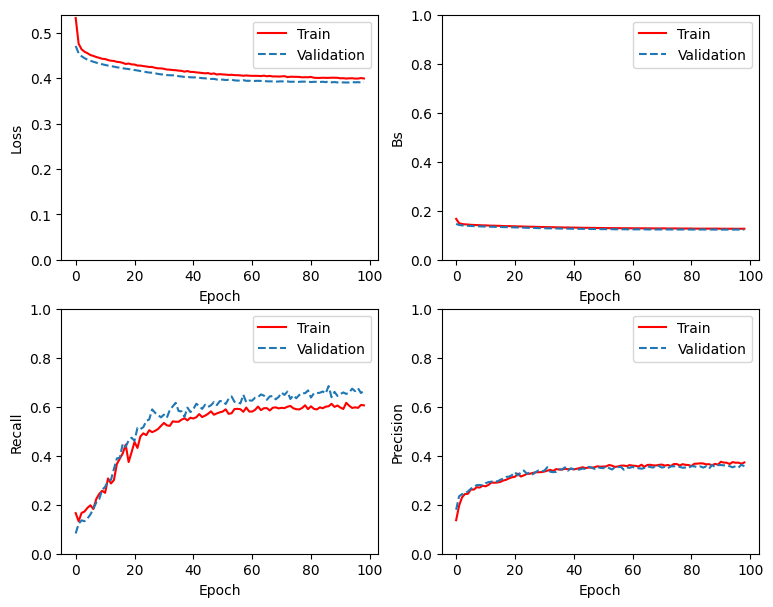

In [298]:
plot_metrics(model_history)

### Performance on testing data

In [299]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

 29/377 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
0.2208872


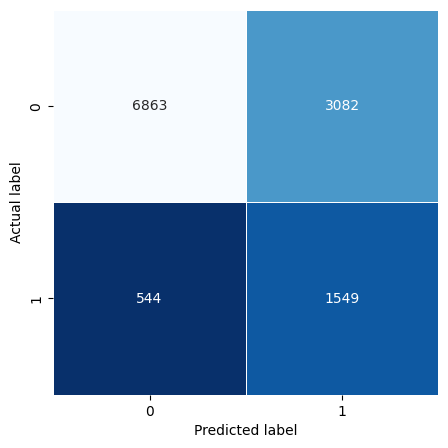

In [300]:
y_hat_val, auc_val, bs_val = class_prediction(x_val, y_val)
classification_threshold_val = cutoff_youdens_j(*roc_curve(y_val, y_hat_val))
print(classification_threshold_val)
plot_cm(y_val, y_hat_val, classification_threshold=classification_threshold_val)

In [301]:
average_precision_score(y_val, y_hat_val)

0.4097443718999879

 20/377 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


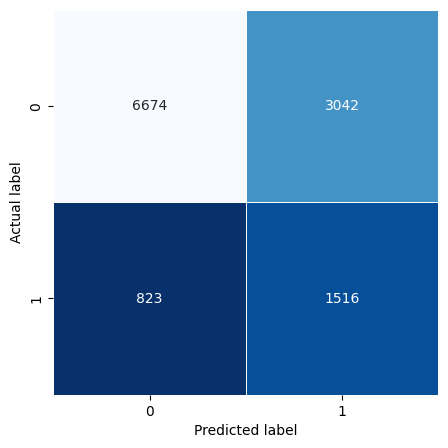

In [302]:
y_hat_test, auc_test, bs_test = class_prediction(x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold_val)

In [303]:
average_precision_score(y_test, y_hat_test)

0.3721634852692553

In [304]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

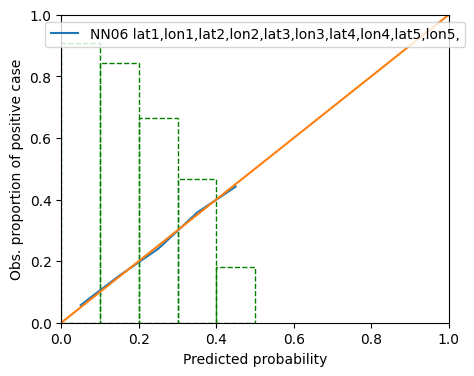

In [305]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN0{lead_time} {location}")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [313]:
model.save(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Bamako-t{lead_time}.keras')

In [307]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [308]:
y_hat_train, auc_train, bs_train = class_prediction(x_train, y_train)

  35/1505 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step 

1505/1505 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [309]:
auc_train

0.7866074852152221

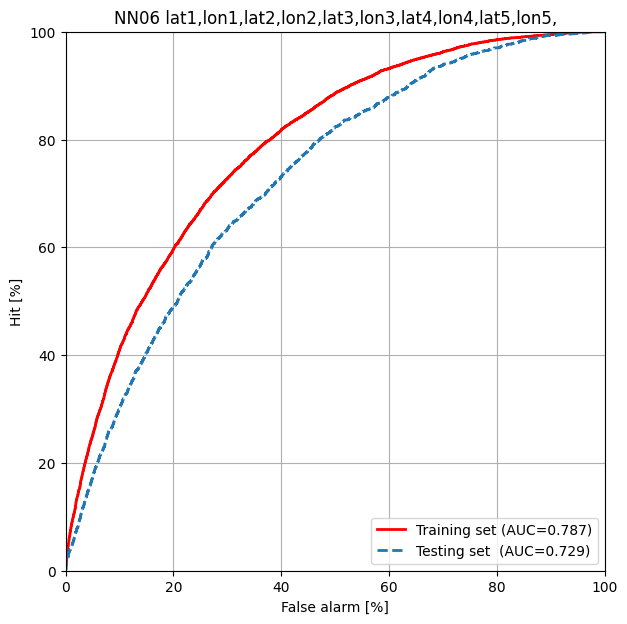

In [310]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train, y_hat_train, color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title(f"NN0{lead_time} {location}")
plt.legend(loc='lower right');

In [311]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

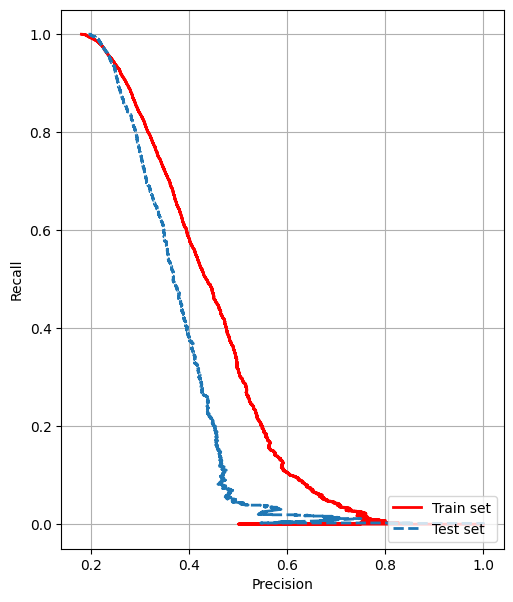

In [312]:
plot_prc("Train set", y_train, y_hat_train, color="red")
plot_prc("Test set", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.legend(loc='lower right');